In [ ]:
import os
print(os.getcwd())
# os.chdir("..")
# print(os.getcwd())
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


c:\Users\bryan\OneDrive - Université Libre de Bruxelles\Master 2 Ingénieur Civile\Master Thesis\MSc_Bryan_Rincon
c:\Users\bryan\OneDrive - Université Libre de Bruxelles\Master 2 Ingénieur Civile\Master Thesis


# Datasets 

In [6]:
# File path to CSV file
VRBA_eruptions_path = "MSc_Bryan_Rincon/VRBA_Eruptions_2019-2024Updated.csv"
Rincon_de_la_Vieja_path = "MSc_Bryan_Rincon/Rincon_de_la_Vieja_continuous_2019-01-01_2025-01-01.csv"
Rincon_path = "MSc_Bryan_Rincon/Rincon 2014-2024.xlsx"


# Load the CSV file into a DataFrame
VRBA_eruptions_df = pd.read_csv(VRBA_eruptions_path)
Rincon_de_la_Vieja_df = pd.read_csv(Rincon_de_la_Vieja_path)
Rincon_df = pd.read_excel(Rincon_path)


# Data exploration

### Dataset Overview

In [7]:
# Drop irrelevant columns
Rincon_de_la_Vieja_df = Rincon_de_la_Vieja_df.drop(columns=['station', 'channel'])

#Convert relevant columns to datetime
VRBA_eruptions_df['t1'] = pd.to_datetime(VRBA_eruptions_df['t1'], format='mixed')
VRBA_eruptions_df['t2'] = pd.to_datetime(VRBA_eruptions_df['t2'], format='mixed')
Rincon_de_la_Vieja_df['time'] = pd.to_datetime(Rincon_de_la_Vieja_df['time'], format='mixed')
Rincon_df['Fecha'] = pd.to_datetime(Rincon_df['Fecha'], format='mixed')



# The basic info and descriptive statistics of the DataFrames are shown below:
print("VRBA Eruptions DataFrame:")
print(VRBA_eruptions_df.info())
print(VRBA_eruptions_df.describe())


print("\nRincon de la Vieja Continuous DataFrame:")
print(Rincon_de_la_Vieja_df.info())
print(Rincon_de_la_Vieja_df.describe())

print("\nRincon DataFrame:")
print(Rincon_df.info())
print(Rincon_df.describe())




VRBA Eruptions DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 957 entries, 0 to 956
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   t1             957 non-null    datetime64[ns]
 1   t2             957 non-null    datetime64[ns]
 2   amplitude_max  957 non-null    float64       
 3   amplitude_rms  957 non-null    float64       
 4   amplitude_p2p  957 non-null    float64       
 5   energy         957 non-null    float64       
dtypes: datetime64[ns](2), float64(4)
memory usage: 45.0 KB
None
                                  t1                             t2  \
count                            957                            957   
mean   2022-09-01 22:52:03.843917312  2022-09-01 22:53:32.683330048   
min       2019-02-02 03:04:51.113000     2019-02-02 03:05:11.377000   
25%    2022-03-19 10:08:08.387000064  2022-03-19 10:09:55.195000064   
50%       2023-01-08 14:29:35.036000     2

c:\Users\bryan\anaconda3\envs\MASTER_THESIS\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


                                time  channel_id          dsar          rsam  \
count                        2501485   2501485.0  2.501484e+06  2.501485e+06   
mean   2021-08-31 07:15:25.727886080         4.0  8.952695e-01  1.083555e+02   
min              2019-01-01 00:01:00         4.0  6.506897e-03  7.330034e-10   
25%              2020-03-14 20:06:00         4.0  5.365507e-01  2.834283e+01   
50%              2021-06-13 09:34:00         4.0  7.610639e-01  4.177987e+01   
75%              2023-02-13 01:54:00         4.0  1.002964e+00  7.173440e+01   
max              2025-01-01 00:00:00         4.0  2.484838e+02  2.822957e+06   
std                              NaN         0.0  7.107066e-01  4.359005e+03   

            trigger  freq_bands_mean    freq_top_k    freq_index  \
count  2.501482e+06     2.501463e+06  2.501472e+06  2.501483e+06   
mean   2.524579e-01     3.915977e+00  2.078415e+00           inf   
min    0.000000e+00     1.298668e+00  8.290285e-01 -5.802415e+00   
25%    

We can see that the VRBA eruptions dataframe has no missing values. When looking closer at the features we see that there's not too much outliers in the data. The Rincon de la Vieja continuous dataframe has a lot missing values in the 'time' and 'value' columns, but not too many. The Rincon dataframe has some missing values in the 'freq_bands_mean','freq_top_k', 'tonality' and 'trigger' columns as well, but again, not too many. Overall, the data seems to be in good shape for further analysis. In contrast, the Rincon dataframe has much more missing values and will require more cleaning before analysis.

We are going to see how many data is missing in the Rincon de la Vieja continuous dataframe.

In [8]:
# Store the first and last time of data being recorded
Rincon_first_time = Rincon_de_la_Vieja_df['time'].min()
Rincon_last_time = Rincon_de_la_Vieja_df['time'].max() 
print(f"\nRincon de la Vieja data recorded from {Rincon_first_time} to {Rincon_last_time}")
# Compute the difference between the two timestamps
difference = (Rincon_last_time - Rincon_first_time).total_seconds() # Duration in seconds
# Convert seconds to minutes
duration_minutes = difference / 60
print(f" Supposed total duration of Rincon de la Vieja data: {duration_minutes} minutes")
# Calculate the actual number of data points recorded
actual_data_points = Rincon_de_la_Vieja_df.shape[0]
print(f" Actual number of data points recorded: {actual_data_points}")# Calculate the expected number of data points for continuous recording every minute
# Compute the number of missing data points
expected_data_points = duration_minutes + 1  # Including both endpoints
missing_data_points = expected_data_points - actual_data_points
print(f" Missing data points: {missing_data_points}")# Calculate the percentage of missing data points
missing_percentage = (missing_data_points / expected_data_points) * 100
print(f" Percentage of missing data points: {missing_percentage:.2f}%")



Rincon de la Vieja data recorded from 2019-01-01 00:01:00 to 2025-01-01 00:00:00
 Supposed total duration of Rincon de la Vieja data: 3156479.0 minutes
 Actual number of data points recorded: 2501485
 Missing data points: 654995.0
 Percentage of missing data points: 20.75%


We see that 20.75% of the data is missing in the Rincon de la Vieja continuous dataframe. Let's see how the missing data points are spread over time.

In [11]:
import pandas as pd

# Suppose ton DataFrame a une colonne 'time' de type datetime
df = Rincon_de_la_Vieja_df.copy()
df = df.sort_values('time')

# Vérifie la fréquence théorique
expected_freq = '1min'

# Recréons une série complète de timestamps attendus
full_range = pd.date_range(df['time'].min(), df['time'].max(), freq=expected_freq)

# Compare ce qui est présent vs manquant
missing_timestamps = full_range.difference(df['time'])
missing_ratio = len(missing_timestamps) / len(full_range)

print(f"Total timestamps expected: {len(full_range)}")
print(f"Actual timestamps present: {df['time'].nunique()}")
print(f"Missing timestamps: {len(missing_timestamps)} ({missing_ratio*100:.2f}%)")


Total timestamps expected: 3156480
Actual timestamps present: 2501485
Missing timestamps: 654995 (20.75%)


In [12]:
df = df.set_index('time').asfreq('1min')
gaps = df.index[df.index.to_series().diff() > pd.Timedelta('2min')]
print("Gaps larger than 2 minutes at:")
print(gaps)


Gaps larger than 2 minutes at:
DatetimeIndex([], dtype='datetime64[ns]', name='time', freq='min')


In [13]:
(df.index.to_series().diff() > pd.Timedelta('1min')).sum()


np.int64(0)

In [14]:
df = Rincon_de_la_Vieja_df.sort_values('time').copy()

# Calculer les intervalles réels entre deux mesures consécutives
time_diffs = df['time'].diff()

# Identifier les écarts supérieurs à 1 minute
gaps = df.loc[time_diffs > pd.Timedelta('2min'), 'time']

print(f"Nombre de gaps détectés : {len(gaps)}")
print("Exemples de gaps :")
print(gaps.head())


Nombre de gaps détectés : 133393
Exemples de gaps :
135101    2019-04-09 03:16:00
639995    2020-03-27 00:01:00
937868    2020-10-21 00:01:00
959453    2020-11-06 00:01:00
1063238   2021-01-17 03:20:00
Name: time, dtype: datetime64[ns]


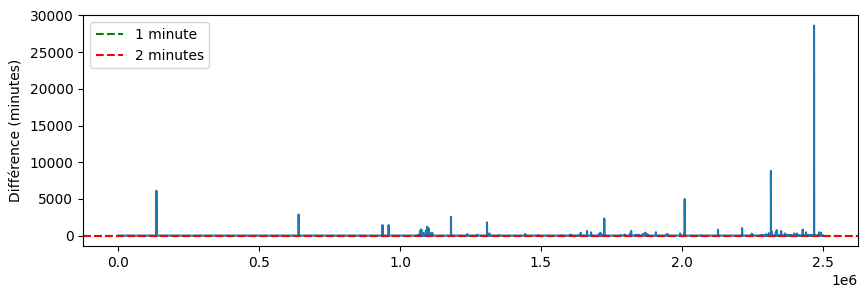

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,3))
plt.plot(df['time'].diff().dt.total_seconds()/60)
plt.axhline(1, color='green', linestyle='--', label='1 minute')
plt.axhline(2, color='red', linestyle='--', label='2 minutes')
plt.legend()
plt.ylabel('Différence (minutes)')
plt.show()


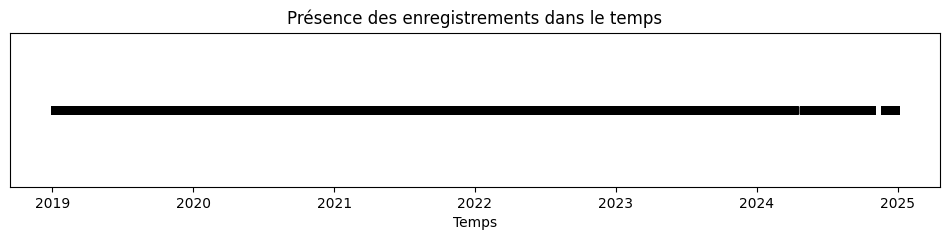

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,2))
plt.plot(df['time'], [1]*len(df), '|', color='black')
plt.title("Présence des enregistrements dans le temps")
plt.yticks([])
plt.xlabel("Temps")
plt.show()


In [17]:
time_diffs = df['time'].diff()
gaps_df = df.loc[time_diffs > pd.Timedelta('2min'), ['time']].copy()
gaps_df['gap_duration_min'] = time_diffs[time_diffs > pd.Timedelta('2min')].dt.total_seconds() / 60

print(gaps_df['gap_duration_min'].describe())


count    133393.000000
mean          4.796106
std          89.476849
min           3.000000
25%           3.000000
50%           3.000000
75%           4.000000
max       28618.000000
Name: gap_duration_min, dtype: float64


In [18]:
expected_minutes = (df['time'].max() - df['time'].min()).total_seconds() / 60
actual_minutes = len(df)
coverage_ratio = actual_minutes / expected_minutes

print(f"Taux de couverture réelle : {coverage_ratio*100:.2f}%")


Taux de couverture réelle : 79.25%


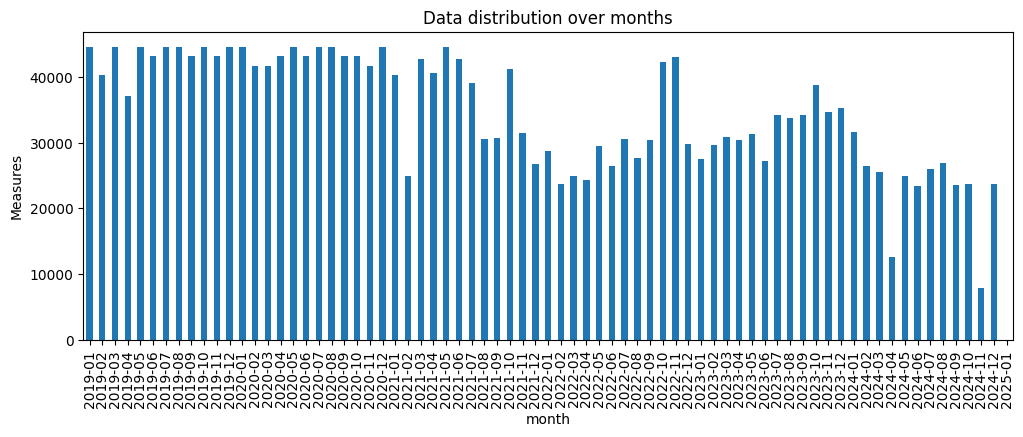

In [25]:
df['month'] = df['time'].dt.to_period('M')
coverage = df.groupby('month')['time'].count()
coverage.plot(kind='bar', figsize=(12,4))
plt.title("Data distribution over months")
plt.ylabel("Measures")
plt.show()


In [23]:
import pandas as pd
import numpy as np

def smart_interpolation(df, value_col, min_seg=10, max_gap=30, bonus_factor=0.5):
    """
    Interpole les gaps temporels selon la qualité des segments voisins.
    
    df : DataFrame indexé par datetime
    value_col : nom de la colonne à interpoler
    min_seg : durée minimale (en min) d’un segment pour être considéré fiable
    max_gap : durée maximale (en min) d’un gap interpolable
    bonus_factor : proportion du segment long utilisable pour corriger plusieurs gaps
    """
    
    df = df.copy()
    df = df.asfreq("1min")  # uniformise la fréquence à 1 min
    mask_nan = df[value_col].isna()

    # Détection des zones continues (segments réels et gaps)
    df['block_id'] = (mask_nan != mask_nan.shift()).cumsum()
    
    blocks = []
    for block_id, block in df.groupby('block_id'):
        is_gap = block[value_col].isna().all()
        duration = len(block)
        start, end = block.index[0], block.index[-1]
        blocks.append({
            "id": block_id,
            "is_gap": is_gap,
            "duration": duration,
            "start": start,
            "end": end
        })
    
    blocks = pd.DataFrame(blocks)
    
    # Itération sur les gaps
    to_interpolate = []
    for i, row in blocks.iterrows():
        if not row.is_gap:
            continue
        
        # Durée du gap (en min)
        gap_dur = row.duration
        
        # Blocs avant et après
        prev_block = blocks.iloc[i-1] if i > 0 else None
        next_block = blocks.iloc[i+1] if i < len(blocks)-1 else None
        
        len_before = prev_block.duration if prev_block is not None else 0
        len_after = next_block.duration if next_block is not None else 0
        
        # Conditions d'interpolation
        can_interp = False
        if gap_dur <= max_gap:
            # Les deux segments doivent être fiables
            if len_before >= min_seg and len_after >= min_seg:
                can_interp = True
            # OU un segment très long peut corriger un gap court
            elif len_before >= min_seg * (1 + bonus_factor) and gap_dur <= max_gap / 2:
                can_interp = True
            elif len_after >= min_seg * (1 + bonus_factor) and gap_dur <= max_gap / 2:
                can_interp = True
        
        if can_interp:
            to_interpolate.append((row.start, row.end))
    
    # Interpolation réelle
    df["is_interpolated"] = False
    for (start, end) in to_interpolate:
        df.loc[start:end, value_col] = df[value_col].interpolate(limit_direction='both')
        df.loc[start:end, "is_interpolated"] = True
    
    return df, blocks, to_interpolate


In [24]:
df_interp, segments, gaps_interp = smart_interpolation(
    df, 
    value_col='time', 
    min_seg=10, 
    max_gap=5, 
    bonus_factor=0.5
)

print(f"{len(gaps_interp)} gaps interpolés sur {len(segments)} segments détectés.")
print("Exemples de gaps interpolés :", gaps_interp[:5])


0 gaps interpolés sur 1 segments détectés.
Exemples de gaps interpolés : []


In [ ]:
# Copy of the time column to analyze missing data
time_df = Rincon_de_la_Vieja_df[['time']].copy()
# Creation of a dictionary to store missing time intervals (as key) and their counts (as value)
min_missing = {}
# Iterate through the time DataFrame to identify missing data points and calculating the time difference
for i in range(1, time_df.shape[0]):
    current_time = time_df.iloc[i]
    previous_time = time_df.iloc[i - 1]
    time_diff = (current_time - previous_time).dt.total_seconds().values[0] / 60  # Convert to minutes
    if time_diff > 1:
        if time_diff not in min_missing:
            min_missing[time_diff] = 0
        min_missing[time_diff] += 1
print("\nMissing time intervals (in minutes) and their counts:")
for interval, count in sorted(min_missing.items()):
    print(f" {interval} minutes: {count} occurrences")


Let's see how the Rincon de la Vieja and Rincon data is distributed over time.

C:\Users\bryan\AppData\Local\Temp\ipykernel_976\2586100561.py:46: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\bryan\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


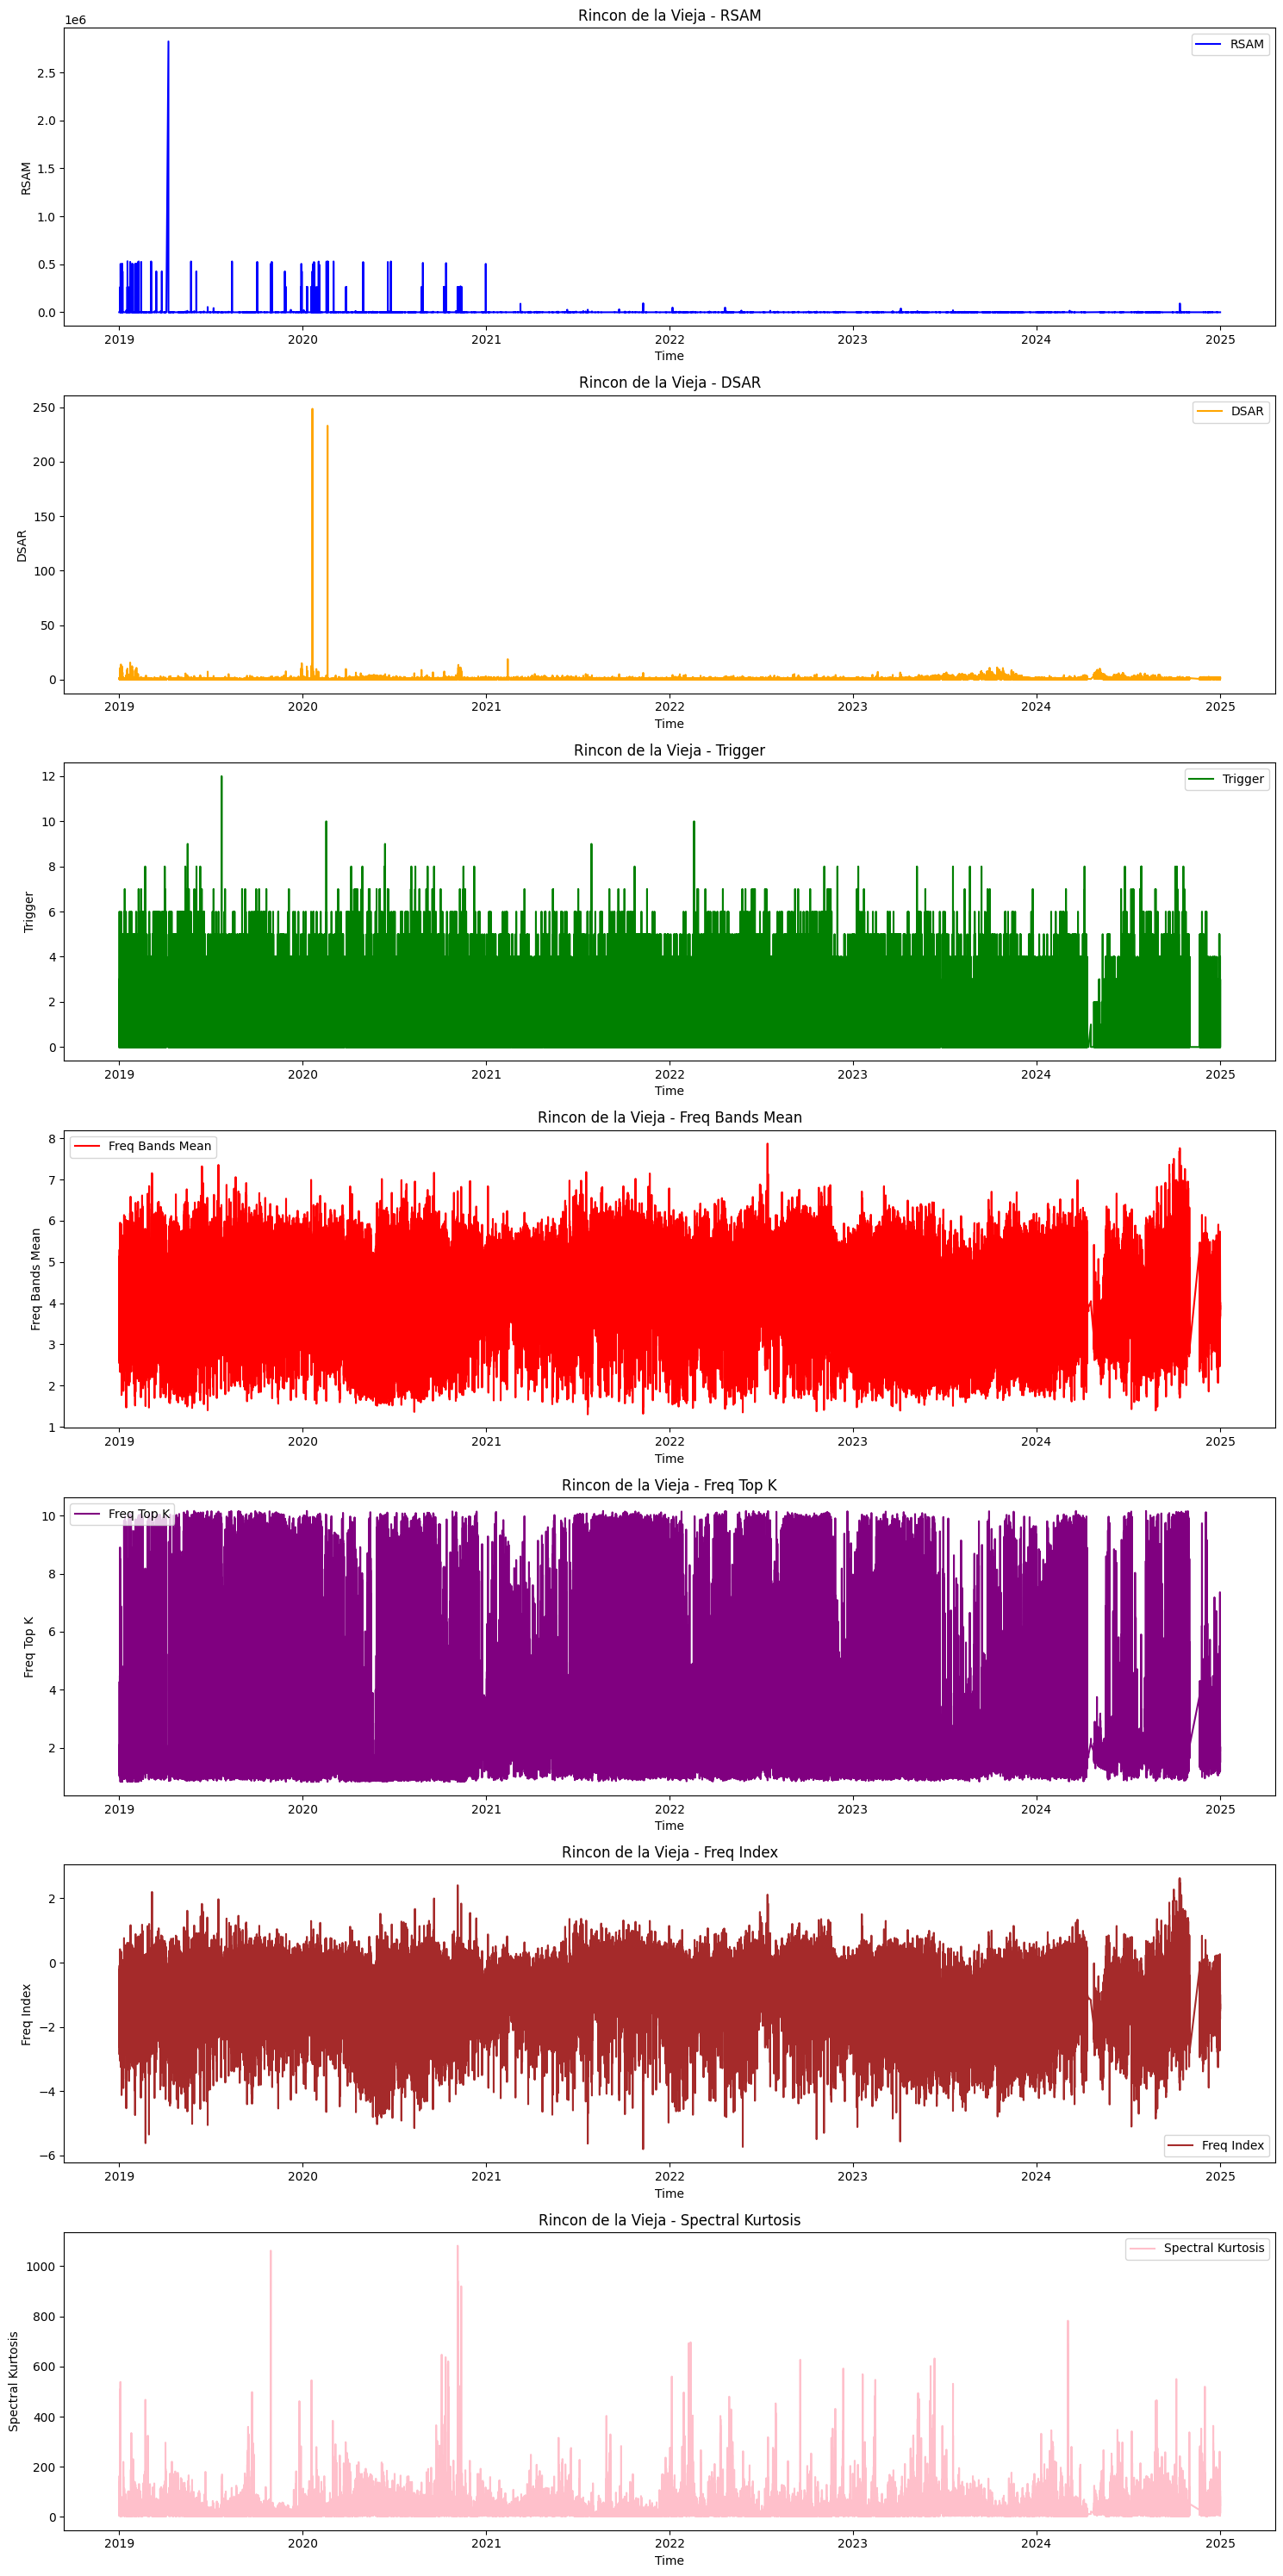

In [6]:
# Plot data
# [dsar , rsam, trigger  freq_bands_mean    freq_top_k    freq_index spectral_kurtosis      tonality]
plt.figure(figsize=(15, 30))
plt.subplot(7, 1, 1)
plt.plot(Rincon_de_la_Vieja_df['time'], Rincon_de_la_Vieja_df['rsam'], label='RSAM', color='blue')
plt.title('Rincon de la Vieja - RSAM')
plt.xlabel('Time')
plt.ylabel('RSAM')
plt.legend()
plt.subplot(7, 1, 2)
plt.plot(Rincon_de_la_Vieja_df['time'], Rincon_de_la_Vieja_df['dsar'], label='DSAR', color='orange')
plt.title('Rincon de la Vieja - DSAR')
plt.xlabel('Time')
plt.ylabel('DSAR')
plt.legend()
plt.subplot(7, 1, 3)
plt.plot(Rincon_de_la_Vieja_df['time'], Rincon_de_la_Vieja_df['trigger'], label='Trigger', color='green')
plt.title('Rincon de la Vieja - Trigger')
plt.xlabel('Time')
plt.ylabel('Trigger')
plt.legend()
plt.subplot(7, 1, 4)
plt.plot(Rincon_de_la_Vieja_df['time'], Rincon_de_la_Vieja_df['freq_bands_mean'], label='Freq Bands Mean', color='red')
plt.title('Rincon de la Vieja - Freq Bands Mean')
plt.xlabel('Time')
plt.ylabel('Freq Bands Mean')
plt.legend()
plt.subplot(7, 1, 5)
plt.plot(Rincon_de_la_Vieja_df['time'], Rincon_de_la_Vieja_df['freq_top_k'], label='Freq Top K', color='purple')
plt.title('Rincon de la Vieja - Freq Top K')
plt.xlabel('Time')
plt.ylabel('Freq Top K')
plt.legend()
plt.subplot(7, 1, 6)
plt.plot(Rincon_de_la_Vieja_df['time'], Rincon_de_la_Vieja_df['freq_index'], label='Freq Index', color='brown')
plt.title('Rincon de la Vieja - Freq Index')
plt.xlabel('Time')
plt.ylabel('Freq Index')
plt.legend()
plt.subplot(7, 1, 7)
plt.plot(Rincon_de_la_Vieja_df['time'], Rincon_de_la_Vieja_df['spectral_kurtosis'], label='Spectral Kurtosis', color='pink')
plt.title('Rincon de la Vieja - Spectral Kurtosis')
plt.xlabel('Time')
plt.ylabel('Spectral Kurtosis')
plt.legend()
plt.tight_layout()
plt.show()

We see some outliers and some missing values in the data. The data will require some cleaning before analysis.

Let's see how the information of the different eruption events are distributed over time.

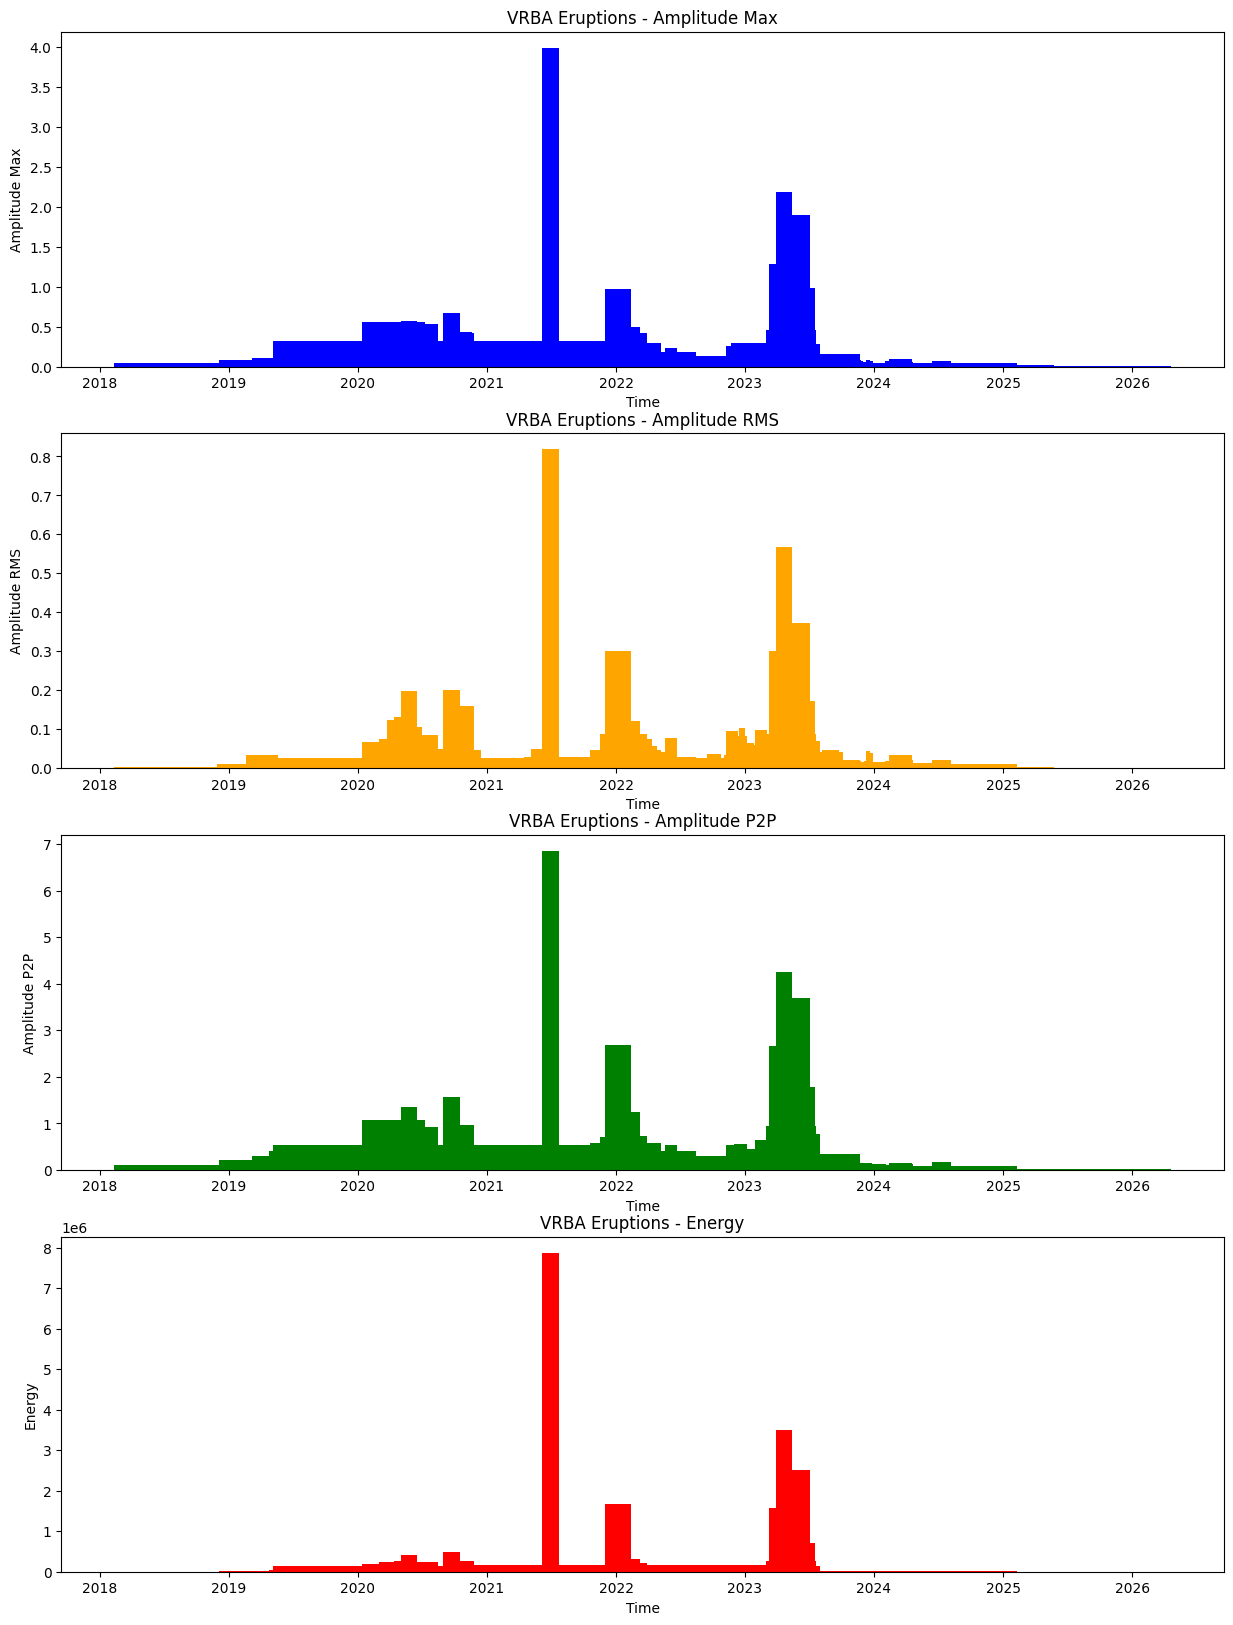

In [7]:
# The data is not in right order. We will sort it by t1, the start time of the eruption
VRBA_eruptions_df = VRBA_eruptions_df.sort_values(by='t1')
# Add new columns showing the duration of the eruption
VRBA_eruptions_df['duration'] = (VRBA_eruptions_df['t2'] - VRBA_eruptions_df['t1']).dt.total_seconds() # Duration in seconds


# Plot a bar graph of the VRBA eruptions
plt.figure(figsize=(15, 20))
plt.subplot(4, 1, 1)
plt.bar(VRBA_eruptions_df['t1'], VRBA_eruptions_df['amplitude_max'], width=VRBA_eruptions_df['duration'], color='blue')
plt.title('VRBA Eruptions - Amplitude Max')
plt.xlabel('Time')
plt.ylabel('Amplitude Max')
plt.subplot(4, 1, 2)
plt.bar(VRBA_eruptions_df['t1'], VRBA_eruptions_df['amplitude_rms'], width=VRBA_eruptions_df['duration'], color='orange')
plt.title('VRBA Eruptions - Amplitude RMS')
plt.xlabel('Time')
plt.ylabel('Amplitude RMS')
plt.subplot(4, 1, 3)
plt.bar(VRBA_eruptions_df['t1'], VRBA_eruptions_df['amplitude_p2p'], width=VRBA_eruptions_df['duration'], color='green')
plt.title('VRBA Eruptions - Amplitude P2P')
plt.xlabel('Time')
plt.ylabel('Amplitude P2P')
plt.subplot(4, 1, 4)
plt.bar(VRBA_eruptions_df['t1'], VRBA_eruptions_df['energy'], width=VRBA_eruptions_df['duration'], color='red')
plt.title('VRBA Eruptions - Energy')
plt.xlabel('Time')
plt.ylabel('Energy')
plt.show()

Let's create a new feature in the VRBA eruptions dataframe that categorizes if the amplitude of the eruption is high or low based on a threshold value. We can use the mean amplitude of all eruptions as the threshold. Then We will add a new column that will tell us if the eruption is a potential lahar or not based on the energy or rms amplitude with the duration of the eruption.

In [8]:
LOW_ENERGY_THRESHOLD = np.percentile(VRBA_eruptions_df['energy'], 50)
MEDIUM_ENERGY_THRESHOLD = np.percentile(VRBA_eruptions_df['energy'], 90)
HIGH_ENERGY_THRESHOLD = np.percentile(VRBA_eruptions_df['energy'], 96)

# print(f"Low Energy Threshold: {LOW_ENERGY_THRESHOLD}")
# print(f"Medium Energy Threshold: {MEDIUM_ENERGY_THRESHOLD}")
# print(f"High Energy Threshold: {HIGH_ENERGY_THRESHOLD}")

def categorize_energy(energy):
    if energy < LOW_ENERGY_THRESHOLD:
        return 'Low'
    elif energy < MEDIUM_ENERGY_THRESHOLD:
        return 'Medium'
    elif energy < HIGH_ENERGY_THRESHOLD:
        return 'High'
    else:
        return 'Very High'

VRBA_eruptions_df['energy_category'] = VRBA_eruptions_df['energy'].apply(categorize_energy)


In [9]:
# Thresholds for detecting potential lahars
ENERGY_THRESHOLD = 1e5
RMS_THRESHOLD = 0.1

# Add new columns for potential lahars
VRBA_eruptions_df['potential_lahar'] = (VRBA_eruptions_df['duration'] > 120) & ((VRBA_eruptions_df['energy'] > ENERGY_THRESHOLD) | (VRBA_eruptions_df['amplitude_rms'] > RMS_THRESHOLD))

print("\nVRBA Eruptions DataFrame with Potential Lahar Column:")
print(VRBA_eruptions_df[['t1', 't2', 'duration', 'energy', 'amplitude_rms', 'potential_lahar']].head())


VRBA Eruptions DataFrame with Potential Lahar Column:
                         t1                      t2  duration    energy  \
616 2019-02-02 03:04:51.113 2019-02-02 03:05:11.377    20.264   294.015   
615 2019-02-06 01:06:17.275 2019-02-06 01:07:49.750    92.475  3255.408   
589 2019-03-30 02:43:59.494 2019-03-30 02:45:05.383    65.889  1292.619   
590 2019-03-31 09:28:15.401 2019-03-31 09:29:28.596    73.195  7302.069   
591 2019-04-01 14:03:50.026 2019-04-01 14:07:56.781   246.755  5482.851   

     amplitude_rms  potential_lahar  
616          0.008            False  
615          0.012            False  
589          0.009            False  
590          0.020            False  
591          0.010            False  


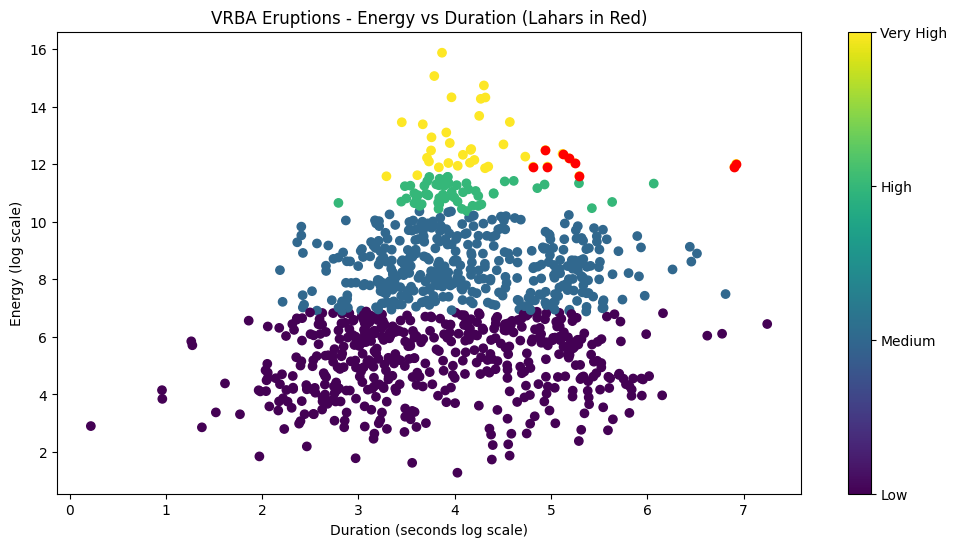

In [10]:
# Map text categories to numbers
category_map = {'Low': 0, 'Medium': 1, 'High': 2, 'Very High': 3}
color_values = VRBA_eruptions_df['energy_category'].map(category_map)

# Scatter plot
plt.figure(figsize=(12, 6))
scatter = plt.scatter(
    np.log(VRBA_eruptions_df['duration']),
    np.log(VRBA_eruptions_df['energy']),
    c=color_values,
    cmap='viridis'
)

# Overlay red points where potential_lahar == True
lahar_df = VRBA_eruptions_df[VRBA_eruptions_df['potential_lahar'] == True]
plt.scatter(
    np.log(lahar_df['duration']),
    np.log(lahar_df['energy']),
    color='red',
    label='Potential Lahar'
)

# Add colorbar with labels
cbar = plt.colorbar(scatter, ticks=[0, 1, 2, 3])
cbar.ax.set_yticklabels(['Low', 'Medium', 'High', 'Very High'])

plt.title('VRBA Eruptions - Energy vs Duration (Lahars in Red)')
plt.xlabel('Duration (seconds log scale)')
plt.ylabel('Energy (log scale)')
plt.show()


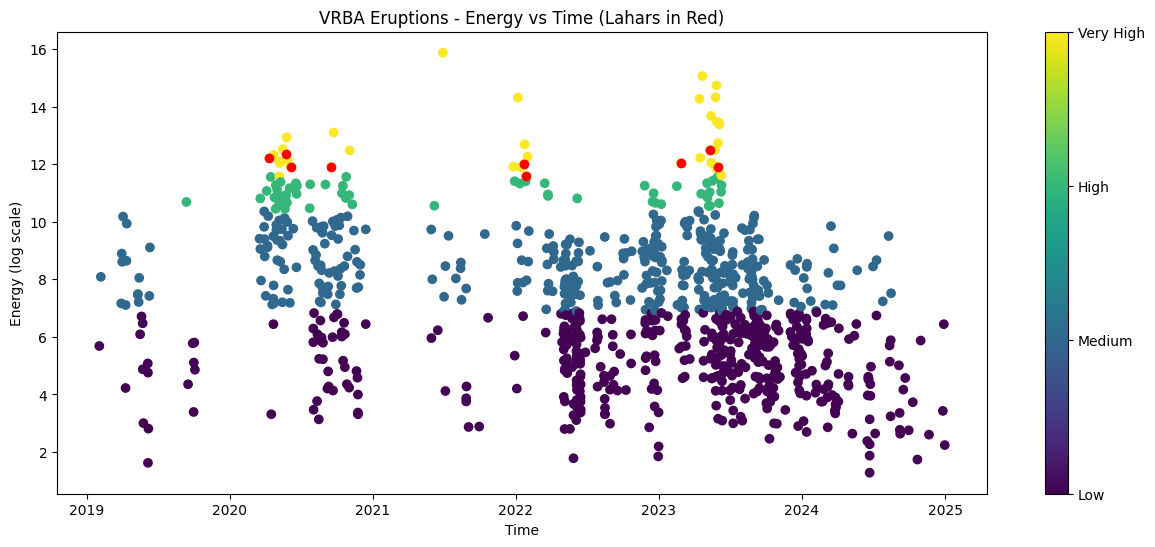

In [11]:
import matplotlib.pyplot as plt

# Map text categories to numbers
category_map = {'Low': 0, 'Medium': 1, 'High': 2, 'Very High': 3}
color_values = VRBA_eruptions_df['energy_category'].map(category_map)

# Scatter plot
plt.figure(figsize=(15, 6))
scatter = plt.scatter(
    VRBA_eruptions_df['t1'],
    np.log(VRBA_eruptions_df['energy']),
    c=color_values,
    cmap='viridis'
)

# Overlay red points where potential_lahar == True
lahar_df = VRBA_eruptions_df[VRBA_eruptions_df['potential_lahar'] == True]
plt.scatter(
    lahar_df['t1'],
    np.log(lahar_df['energy']),
    color='red',
    label='Potential Lahar'
)

# Add colorbar with labels
cbar = plt.colorbar(scatter, ticks=[0, 1, 2, 3])
cbar.ax.set_yticklabels(['Low', 'Medium', 'High', 'Very High'])

plt.title('VRBA Eruptions - Energy vs Time (Lahars in Red)')
plt.xlabel('Time')
plt.ylabel('Energy (log scale)')
plt.show()


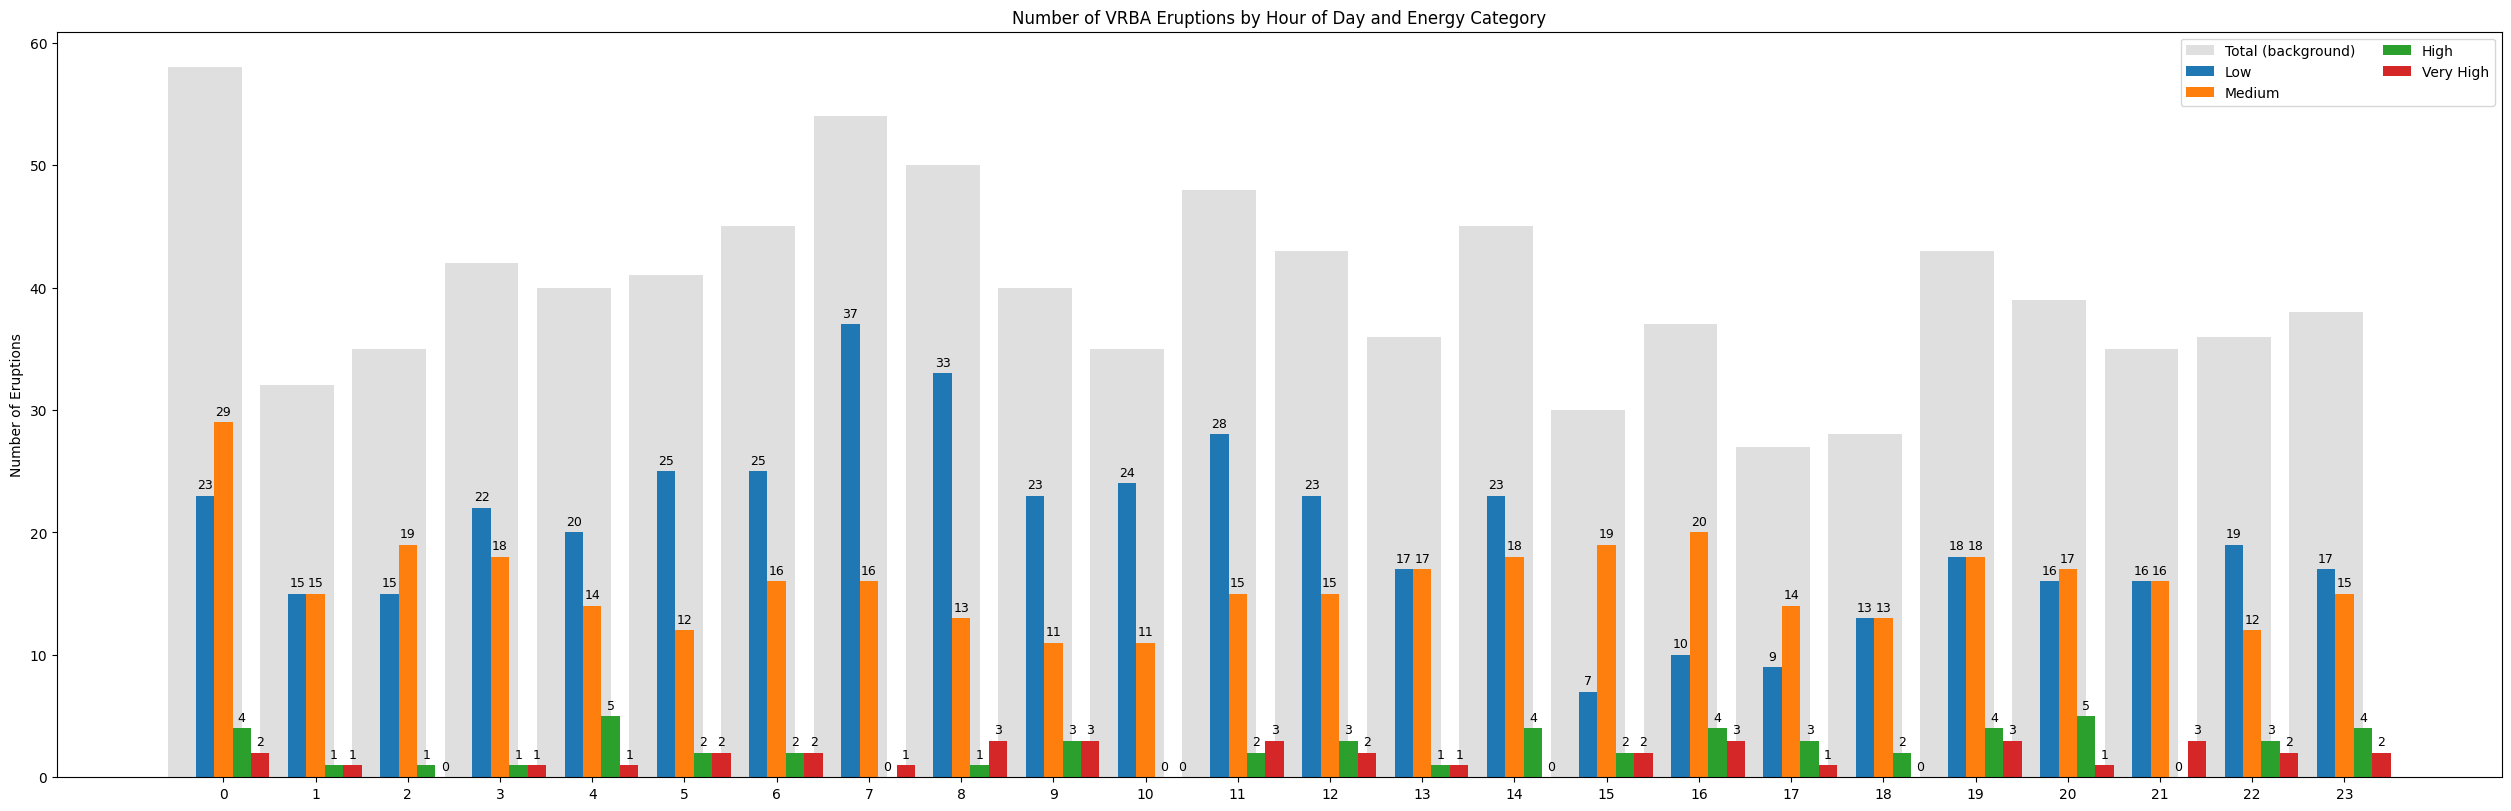

In [12]:
# Plot the the number of eruptions per category of energy in function of the time of the day (hour)
energy_categories = {}
for energy in VRBA_eruptions_df['energy_category'].unique():
    counts = (
            VRBA_eruptions_df[VRBA_eruptions_df['energy_category'] == energy]['t1']
            .dt.hour.value_counts()
            .sort_index()
        )
    # S'assurer que toutes les heures (0-23) sont présentes
    counts = counts.reindex(np.arange(24), fill_value=0)
    energy_categories[energy] = counts

total_counts = sum(energy_categories.values())

# Plot the the number of eruptions per category of energy in function of the time of the day (hour)
hours = list(range(24))
x = np.arange(len(hours))
width = 0.2  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(layout='constrained', figsize=(25, 8))

ax.bar(
    x,
    total_counts,
    width=0.8,
    color='gray',
    alpha=0.25,  # transparence
    label='Total (background)',
    zorder=0     # bien en arrière-plan
)

for energy, counts in energy_categories.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, counts, width, label=energy)
    ax.bar_label(rects, padding=3, fontsize=9)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Number of Eruptions')
ax.set_title('Number of VRBA Eruptions by Hour of Day and Energy Category')
ax.set_xticks(x + width, hours)
ax.legend(loc='upper right', ncols=2)
ax.autoscale_view()
plt.show()


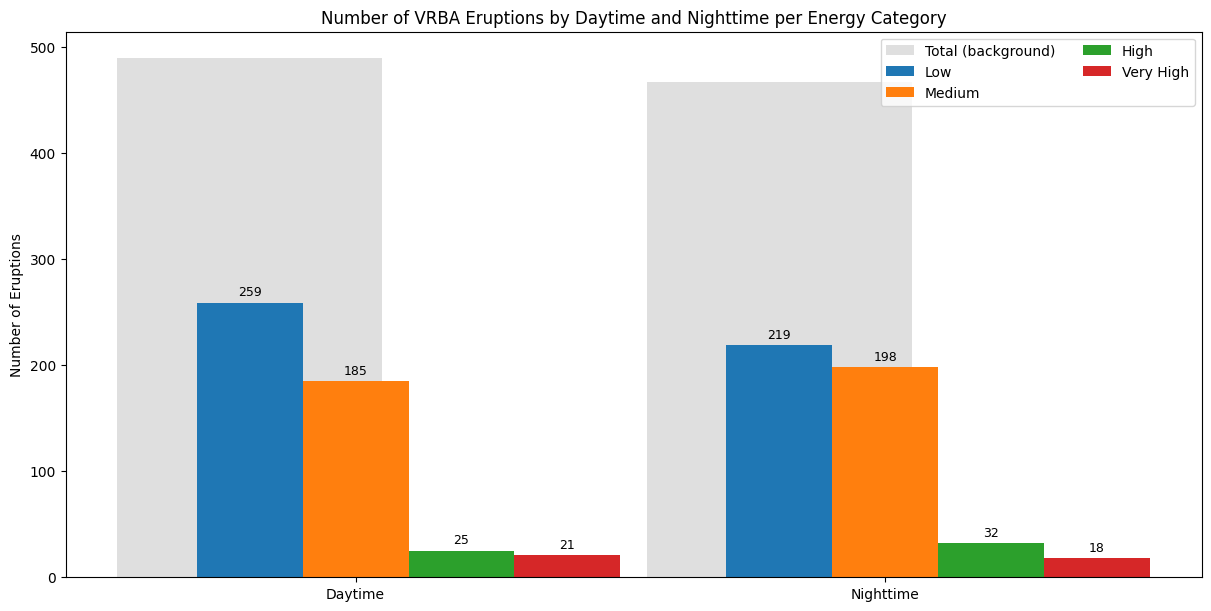

In [13]:
# Lets separate the day into night and daytime
energy_categories = {}
for energy in VRBA_eruptions_df['energy_category'].unique():
    energy_categories[energy] = {'daytime': [], 'nighttime': []}
    for hour, count in VRBA_eruptions_df[VRBA_eruptions_df['energy_category'] == energy]['t1'].dt.hour.value_counts().items():
        if 5.75 <= hour < 17.75:
            energy_categories[energy]['daytime'].append(count)
        else:
            energy_categories[energy]['nighttime'].append(count)

total_daytime = sum(sum(c['daytime']) for c in energy_categories.values())
total_nighttime = sum(sum(c['nighttime']) for c in energy_categories.values())
total_counts = [total_daytime, total_nighttime]

# Plot the number of eruptions during daytime and nighttime per energy category
labels = ['Daytime', 'Nighttime']
x = np.arange(len(labels))
width = 0.2  # the width of the bars
multiplier = 0
fig, ax = plt.subplots(layout='constrained', figsize=(12, 6))

ax.bar(
    x,
    total_counts,
    width=0.5,
    color='gray',
    alpha=0.25,  # transparence
    label='Total (background)',
    zorder=0     # bien en arrière-plan
)

for energy, counts in energy_categories.items():
    offset = width * multiplier
    values = [sum(counts['daytime']), sum(counts['nighttime'])]
    rects = ax.bar(x + offset, values, width, label=energy)
    ax.bar_label(rects, padding=3, fontsize=9)
    multiplier += 1
# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Number of Eruptions')
ax.set_title('Number of VRBA Eruptions by Daytime and Nighttime per Energy Category')
ax.set_xticks(x + width, labels)
ax.legend(loc='upper right', ncols=2)
ax.autoscale_view()
plt.show()


# Data preparation (features extraction,...)

We can use the seasons in costa rica to categorize the eruptions in VRBA. The dry season is from December to April and the wet season is from May to November. We can create a new column in the VRBA eruptions dataframe that will tell us if the eruption happened in the dry or wet season.
https://costa-rica-guide.com/travel/weather/seasons-in-costa-rica/

In [14]:
VRBA_eruptions_df['season'] = VRBA_eruptions_df['t1'].dt.month.apply(lambda month: 'Dry' if month in [12, 1, 2, 3, 4] else 'Wet')

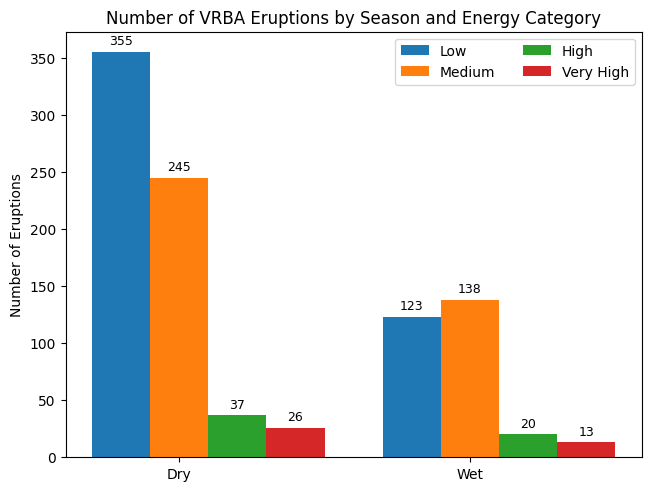

In [15]:
# Plot the the number of eruptions per category of energy in function of the time of the day (hour)
energy_categories = {}
for energy in VRBA_eruptions_df['energy_category'].unique():
    energy_categories[energy] = VRBA_eruptions_df[VRBA_eruptions_df['energy_category'] == energy]['season'].value_counts()
# Plot the results
seasons = VRBA_eruptions_df['season'].unique()
x = np.arange(len(seasons))
width = 0.2  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(layout='constrained')

for energy, counts in energy_categories.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, counts, width, label=energy)
    ax.bar_label(rects, padding=3, fontsize=9)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Number of Eruptions')
ax.set_title('Number of VRBA Eruptions by Season and Energy Category')
ax.set_xticks(x + width, seasons)
ax.legend(loc='upper right', ncols=2)
ax.autoscale_view()
plt.show()


C:\Users\bryan\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


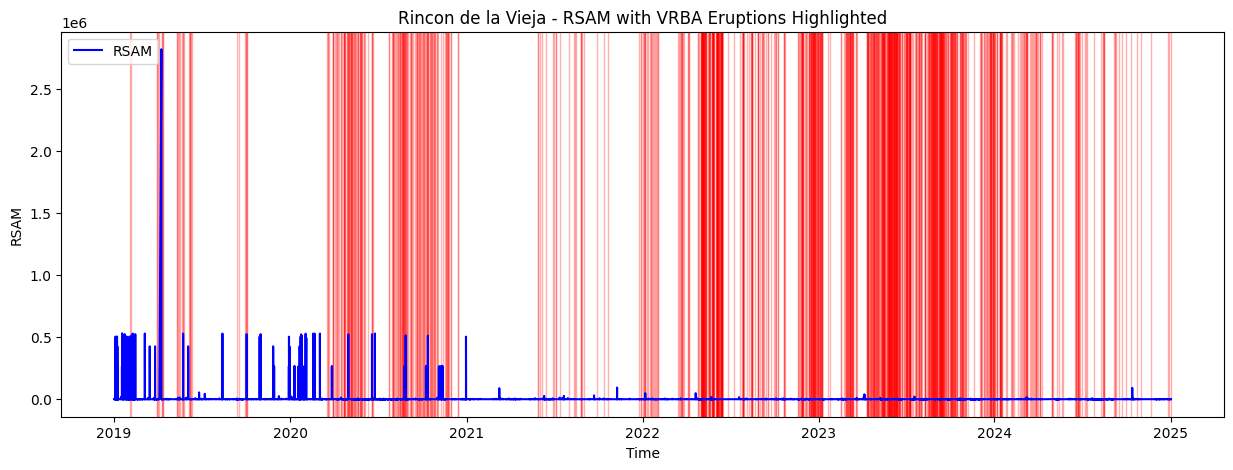

C:\Users\bryan\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


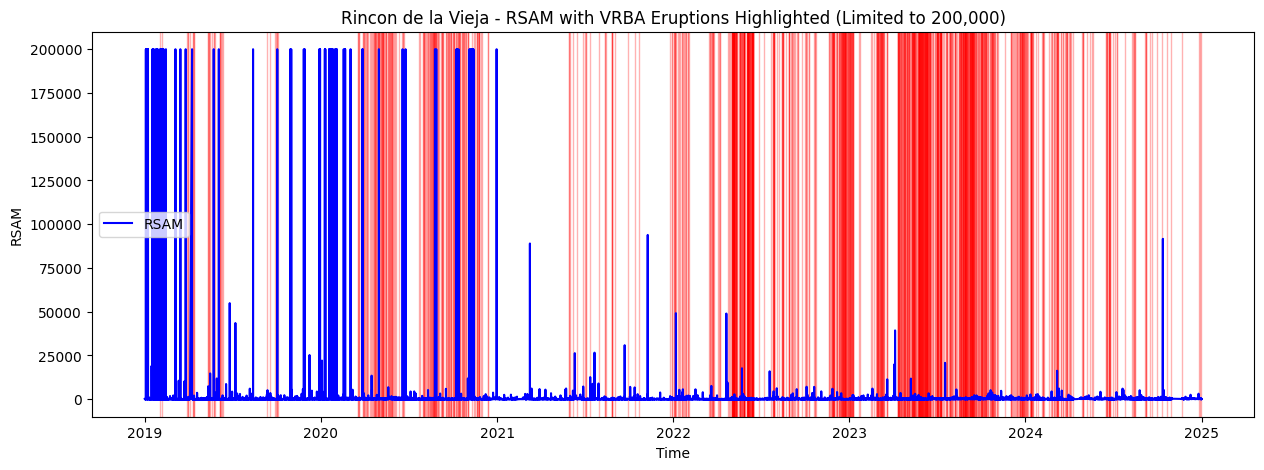

In [16]:
# Plot the VRBA eruptions
#VRBA_eruptions_df['t1'] and VRBA_eruptions_df['t2']

plt.figure(figsize=(15, 5))
for index, eruption in VRBA_eruptions_df.iterrows():
    plt.axvspan(eruption['t1'], eruption['t2'], color='red', alpha=0.3)
#ed_mask, 'rsam'] = np.nan
plt.plot(Rincon_de_la_Vieja_df['time'], Rincon_de_la_Vieja_df['rsam'], label='RSAM', color='blue')
plt.title('Rincon de la Vieja - RSAM with VRBA Eruptions Highlighted')
plt.xlabel('Time')
plt.ylabel('RSAM')
plt.legend()
plt.show()
import numpy as np
# Limit Rsam to 2*1e6
Rincon_de_la_Vieja_df['Rsam'] = np.where(Rincon_de_la_Vieja_df['rsam'] > 0.2*1e6, 0.2*1e6, Rincon_de_la_Vieja_df['rsam'])
# Plot the VRBA eruptions
#VRBA_eruptions_df['t1'] and VRBA_eruptions_df['t2']
# Print null value of Rincon_de_la_Vieja_df['Rsam'] in green
plt.figure(figsize=(15, 5))
plt.plot(Rincon_de_la_Vieja_df['time'], Rincon_de_la_Vieja_df['Rsam'], label='RSAM', color='blue')
plt.scatter(Rincon_de_la_Vieja_df['time'][Rincon_de_la_Vieja_df['Rsam'].isnull()], Rincon_de_la_Vieja_df['Rsam'][Rincon_de_la_Vieja_df['Rsam'].isnull()], color='green')
for index, eruption in VRBA_eruptions_df.iterrows():
    plt.axvspan(eruption['t1'], eruption['t2'], color='red', alpha=0.3)
plt.title('Rincon de la Vieja - RSAM with VRBA Eruptions Highlighted (Limited to 200,000)')
plt.xlabel('Time')
plt.ylabel('RSAM')
plt.legend()
plt.show()

Lets get the corresponding Rsam values from Rincon de la Vieja for each eruption in VRBA.

In [17]:
merged_df = pd.merge_asof(VRBA_eruptions_df[['t1']].sort_values('t1'), Rincon_de_la_Vieja_df.sort_values('time'), left_on='t1', right_on='time', direction='backward', tolerance=pd.Timedelta('1h'))
matched_time = merged_df[['t1', 'time']]
matched_time.to_csv("MSc_Bryan_Rincon/merged_Rincon.csv", index=False)


Lets analyze the Rsam values from Rincon de la Vieja just before the eruptions in VRBA. We want to prevent populutation of an eruption at least 7 minutes before it happens. We will thus take an averge value and standard deviation of Rsam values from Rincon de la Vieja in the time window of 7 to 60 minutes before each eruption in VRBA. (POSSIBLE DE REDUIRE LINTERVALLE POUR PLUS DE PRECISION)

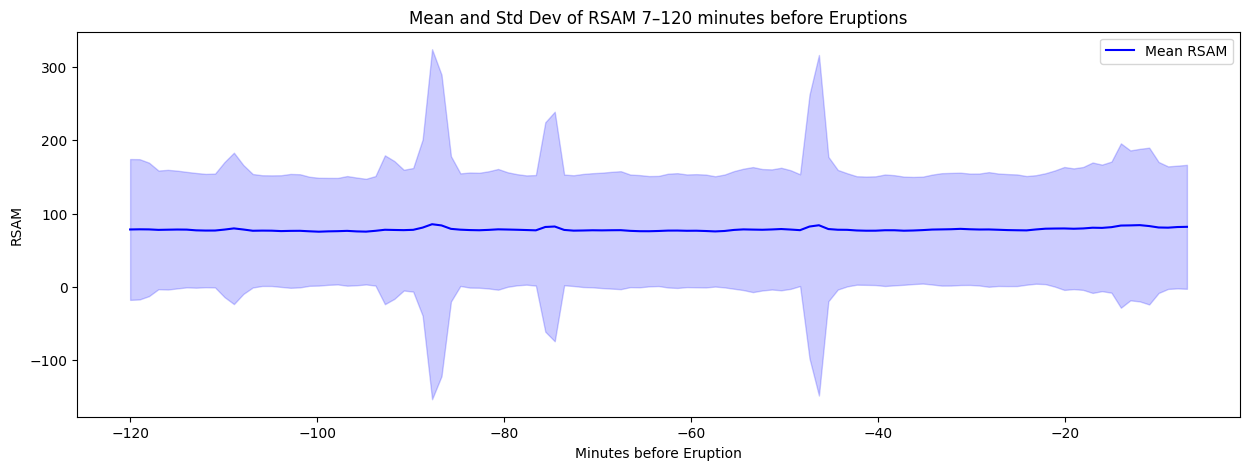

In [18]:
# #
# for index, eruption in matched_time.iterrows():
#     last_evaluation = eruption['t1']
#     eruption_time = eruption['time']
#     # Mean observation of 7 to 60 minutes before eruption
#     start_time = last_evaluation - pd.Timedelta(minutes=120)
#     end_time = last_evaluation - pd.Timedelta(minutes=7)
#     window_data = Rincon_de_la_Vieja_df[(Rincon_de_la_Vieja_df['time'] >= start_time) & (Rincon_de_la_Vieja_df['time'] <= end_time)]
#     avg_rsam = window_data['Rsam'].mean()
#     std_rsam = window_data['Rsam'].std()
#     #print(f"Eruption at {last_evaluation}: Avg RSAM = {avg_rsam}, Std RSAM = {std_rsam}")


# # Plot 270 minutes before each eruption (50 example)
# observation_time_minutes = 270
# plt.figure(figsize=(15, 580))
# n_examples = min(50, len(matched_time))
# for i in range(n_examples):
#     eruption = matched_time.iloc[i+500]  # Offset by 500 to avoid the first eruptions
#     last_evaluation = eruption['t1']
#     eruption_time = eruption['time']
#     start_time = last_evaluation - pd.Timedelta(minutes=observation_time_minutes)
#     end_time = last_evaluation
#     window_data = Rincon_de_la_Vieja_df[(Rincon_de_la_Vieja_df['time'] >= start_time) & (Rincon_de_la_Vieja_df['time'] <= end_time)]
#     plt.subplot(n_examples, 1, i+1)
#     plt.plot(window_data['time'], window_data['Rsam'], label='RSAM', color='blue')
#     plt.title(f'Rincon de la Vieja - RSAM {observation_time_minutes} minutes before Eruption at {last_evaluation}')
#     plt.xlabel('Time')
#     plt.ylabel('RSAM')
#     plt.axvline(x=last_evaluation, color='red', linestyle='--', label='Eruption Time')
#     plt.legend()


# plt.tight_layout()
# plt.show()


window_synthesis = []
num_points = 113  # same as len(time_axis) = 120 - 7 + 1 = 113, adjust if needed

for _, eruption in matched_time.iterrows():
    last_evaluation = eruption['t1']
    start_time = last_evaluation - pd.Timedelta(minutes=120)
    end_time = last_evaluation - pd.Timedelta(minutes=7)

    window_data = Rincon_de_la_Vieja_df[(Rincon_de_la_Vieja_df['time'] >= start_time) & (Rincon_de_la_Vieja_df['time'] <= end_time)]

    if len(window_data) > 1:
        # Convert time to minutes before eruption
        minutes_before = (window_data['time'] - end_time).dt.total_seconds() / 60
        # Interpolate to uniform grid
        new_time = np.linspace(minutes_before.min(), minutes_before.max(), num_points)
        interp_values = np.interp(new_time, minutes_before, window_data['Rsam'])
        window_synthesis.append(interp_values)

# Compute mean and std
Mean_window = np.nanmean(np.vstack(window_synthesis), axis=0)
Std_window = np.nanstd(np.vstack(window_synthesis), axis=0)

time_axis = np.linspace(-120, -7, num_points)

plt.figure(figsize=(15, 5))
plt.plot(time_axis, Mean_window, label='Mean RSAM', color='blue')
plt.fill_between(time_axis, Mean_window - Std_window, Mean_window + Std_window, color='blue', alpha=0.2)
plt.title('Mean and Std Dev of RSAM 7–120 minutes before Eruptions')
plt.xlabel('Minutes before Eruption')
plt.ylabel('RSAM')
plt.legend()
plt.show()

    


In [19]:
# Lets analyze the energy categories in relation to the mean RSAM before eruptions
energy_category_windows = {category: [] for category in VRBA_eruptions_df['energy_category'].unique()}

for _, eruption in matched_time.iterrows():
    last_evaluation = eruption['t1']
    start_time = last_evaluation - pd.Timedelta(minutes=120)
    end_time = last_evaluation - pd.Timedelta(minutes=7)

    window_data = Rincon_de_la_Vieja_df[
        (Rincon_de_la_Vieja_df['time'] >= start_time) &
        (Rincon_de_la_Vieja_df['time'] <= end_time)
    ][['time', 'Rsam']].dropna()

    if len(window_data) > 1:
        # Convert time to minutes before eruption
        minutes_before = (window_data['time'] - end_time).dt.total_seconds() / 60
        # Interpolate to uniform grid
        new_time = np.linspace(minutes_before.min(), minutes_before.max(), num_points)
        interp_values = np.interp(new_time, minutes_before, window_data['Rsam'])
        energy_category_windows[eruption['energy_category']].append(interp_values)

# Compute mean and std for each energy category
energy_category_means = {category: np.nanmean(np.vstack(windows), axis=0) for category, windows in energy_category_windows.items()}
energy_category_stds = {category: np.nanstd(np.vstack(windows), axis=0) for category, windows in energy_category_windows.items()}
time_axis = np.linspace(-113, -7, num_points)
plt.figure(figsize=(15, 10))
for category in energy_category_means.keys():
    plt.plot(time_axis, energy_category_means[category], label=f'Mean RSAM - {category}')
    plt.fill_between(time_axis,
                     energy_category_means[category] - energy_category_stds[category],
                     energy_category_means[category] + energy_category_stds[category],
                     alpha=0.2)
plt.title('Mean and Std Dev of RSAM 7–120 minutes before Eruptions by Energy Category')
plt.xlabel('Minutes before Eruption')
plt.ylabel('RSAM')
plt.legend()
plt.show()

KeyError: 'energy_category'

In [ ]:
# # 120 minutes before eruption
# for index, eruption in matched_time.iterrows():
#     last_evaluation = eruption['t1']
#     eruption_time = eruption['time']
#     # Mean observation of 7 to 60 minutes before eruption
#     start_time = last_evaluation - pd.Timedelta(minutes=120)
#     end_time = last_evaluation - pd.Timedelta(minutes=7)
#     window_data = Rsam_Rincon[(Rsam_Rincon['time'] >= start_time) & (Rsam_Rincon['time'] <= end_time)]
#     avg_rsam = window_data['Rsam'].mean()
#     std_rsam = window_data['Rsam'].std()
#     #print(f"Eruption at {last_evaluation}: Avg RSAM = {avg_rsam}, Std RSAM = {std_rsam}")


# Plot 270 minutes before each eruption (50 example)
observation_time_minutes = 270
plt.figure(figsize=(15, 580))
n_examples = min(50, len(matched_time))
for i in range(n_examples):
    eruption = matched_time.iloc[i+500]  # Offset by 500 to avoid the first eruptions
    last_evaluation = eruption['t1']
    eruption_time = eruption['time']
    start_time = last_evaluation - pd.Timedelta(minutes=observation_time_minutes)
    end_time = last_evaluation
    window_data = Rsam_Rincon[(Rsam_Rincon['time'] >= start_time) & (Rsam_Rincon['time'] <= end_time)]
    plt.subplot(n_examples, 1, i+1)
    plt.plot(window_data['time'], window_data['rsam'], label='RSAM', color='blue')
    plt.title(f'Rincon de la Vieja - RSAM {observation_time_minutes} minutes before Eruption at {last_evaluation}')
    plt.xlabel('Time')
    plt.ylabel('RSAM')
    plt.axvline(x=last_evaluation, color='red', linestyle='--', label='Eruption Time')
    plt.legend()


plt.tight_layout()
plt.show()


window_synthesis = []
num_points = 7164   # same as len(time_axis) = 7200 - 7 + 1 = 113, adjust if needed

for _, eruption in matched_time.iterrows():
    last_evaluation = eruption['t1']
    start_time = last_evaluation - pd.Timedelta(minutes=7200)
    end_time = last_evaluation - pd.Timedelta(minutes=7)

    window_data = Rsam_Rincon[(Rsam_Rincon['time'] >= start_time) & (Rsam_Rincon['time'] <= end_time)]

    if len(window_data) > 1:
        # Convert time to minutes before eruption
        minutes_before = (window_data['time'] - end_time).dt.total_seconds() / 60
        # Interpolate to uniform grid
        new_time = np.linspace(minutes_before.min(), minutes_before.max(), num_points)
        interp_values = np.interp(new_time, minutes_before, window_data['rsam'])
        window_synthesis.append(interp_values)

# Compute mean and std
Mean_window = np.nanmean(np.vstack(window_synthesis), axis=0)
Std_window = np.nanstd(np.vstack(window_synthesis), axis=0)

time_axis = np.linspace(-7200, -7, num_points)

plt.figure(figsize=(15, 5))
plt.plot(time_axis, Mean_window, label='Mean RSAM', color='blue')
plt.fill_between(time_axis, Mean_window - Std_window, Mean_window + Std_window, color='blue', alpha=0.2)
plt.title('Mean and Std Dev of RSAM 7–7200 minutes before Eruptions')
plt.xlabel('Minutes before Eruption')
plt.ylabel('RSAM')
plt.legend()
plt.show()

    

window_synthesis = []
max_observation_time = 4*60
num_points = max_observation_time - 7 + 1     # same as len(time_axis) = 7200 - 7 + 1 = 113, adjust if needed


lahar_df = VRBA_eruptions_df[VRBA_eruptions_df["Lahares"] == True]
matched_time = pd.merge_asof(lahar_df[['t1']].sort_values('t1'), Rsam_Rincon.sort_values('time'), left_on='t1', right_on='time', direction='backward', tolerance=pd.Timedelta('1h'))
for _, eruption in matched_time.iterrows():
    last_evaluation = eruption['t1']
    start_time = last_evaluation - pd.Timedelta(minutes=max_observation_time)
    end_time = last_evaluation - pd.Timedelta(minutes=7)

    window_data = Rsam_Rincon[(Rsam_Rincon['time'] >= start_time) & (Rsam_Rincon['time'] <= end_time)]

    if len(window_data) > 1:
        # Convert time to minutes before eruption
        minutes_before = (window_data['time'] - end_time).dt.total_seconds() / 60
        # Interpolate to uniform grid
        new_time = np.linspace(minutes_before.min(), minutes_before.max(), num_points)
        interp_values = np.interp(new_time, minutes_before, window_data['rsam'])
        window_synthesis.append(interp_values)

# Compute mean and std
Mean_window = np.nanmedian(np.vstack(window_synthesis), axis=0)
Std_window = np.nanstd(np.vstack(window_synthesis), axis=0)

time_axis = np.linspace(-max_observation_time, -7, num_points)

plt.figure(figsize=(15, 15))
plt.plot(time_axis, Mean_window, label='Mean RSAM', color='red')
plt.fill_between(time_axis, Mean_window - Std_window, Mean_window + Std_window, color='white', alpha=0.5)
plt.title(f'Mean and Std Dev of RSAM 7–{max_observation_time} minutes before Eruptions')
plt.xlabel('Minutes before Eruption')
plt.ylabel('RSAM')
plt.legend()
plt.show()

# Lets analyze the energy categories in relation to the mean RSAM before eruptions
energy_category_windows = {category: [] for category in VRBA_eruptions_df['energy_category'].unique()}

for _, eruption in matched_time.iterrows():
    last_evaluation = eruption['t1']
    start_time = last_evaluation - pd.Timedelta(minutes=120)
    end_time = last_evaluation - pd.Timedelta(minutes=7)

    window_data = Rincon_de_la_Vieja_df[
        (Rincon_de_la_Vieja_df['time'] >= start_time) &
        (Rincon_de_la_Vieja_df['time'] <= end_time)
    ][['time', 'Rsam']].dropna()

    if len(window_data) > 1:
        # Convert time to minutes before eruption
        minutes_before = (window_data['time'] - end_time).dt.total_seconds() / 60
        # Interpolate to uniform grid
        new_time = np.linspace(minutes_before.min(), minutes_before.max(), num_points)
        interp_values = np.interp(new_time, minutes_before, window_data['Rsam'])
        energy_category_windows[eruption['energy_category']].append(interp_values)

# Compute mean and std for each energy category
energy_category_means = {category: np.nanmean(np.vstack(windows), axis=0) for category, windows in energy_category_windows.items()}
energy_category_stds = {category: np.nanstd(np.vstack(windows), axis=0) for category, windows in energy_category_windows.items()}
time_axis = np.linspace(-113, -7, num_points)
plt.figure(figsize=(15, 10))
for category in energy_category_means.keys():
    plt.plot(time_axis, energy_category_means[category], label=f'Mean RSAM - {category}')
    plt.fill_between(time_axis,
                     energy_category_means[category] - energy_category_stds[category],
                     energy_category_means[category] + energy_category_stds[category],
                     alpha=0.2)
plt.title('Mean and Std Dev of RSAM 7–120 minutes before Eruptions by Energy Category')
plt.xlabel('Minutes before Eruption')
plt.ylabel('RSAM')
plt.legend()
plt.show()
# ...existing code...
# Lets analyze the energy categories in relation to the mean RSAM before eruptions

# Ensure num_points exists
num_points = 7164  # 7200 to 7 minutes -> 7164 samples if excluding one endpoint

energy_category_windows = {category: [] for category in VRBA_eruptions_df['energy_category'].unique()}

for _, eruption in VRBA_eruptions_df.iterrows():
    last_evaluation = eruption['t1']
    start_time = last_evaluation - pd.Timedelta(minutes=7200)
    end_time = last_evaluation - pd.Timedelta(minutes=7)

    window_data = Rsam_Rincon[
        (Rsam_Rincon['time'] >= start_time) &
        (Rsam_Rincon['time'] <= end_time)
    ][['time', 'Rsam']].dropna()

    if len(window_data) > 1:
        # Minutes relative to the end of the window (−7200 to 0), where 0 = 7 min before eruption
        minutes_before = (window_data['time'] - end_time).dt.total_seconds() / 60.0  # negative to 0
        new_time = np.linspace(minutes_before.min(), minutes_before.max(), num_points)
        interp_values = np.interp(new_time, minutes_before, window_data['Rsam'])
        energy_category_windows[eruption['energy_category']].append(interp_values)

# Compute mean and std for each energy category (skip empty categories)
energy_category_means = {
    category: np.nanmean(np.vstack(windows), axis=0)
    for category, windows in energy_category_windows.items() if len(windows) > 0
}
energy_category_stds = {
    category: np.nanstd(np.vstack(windows), axis=0)
    for category, windows in energy_category_windows.items() if len(windows) > 0
}

# X-axis: minutes before eruption, covering the window [-7200, -7]
time_axis = np.linspace(-7200, -7, num_points)

plt.figure(figsize=(40, 20))
for category in energy_category_means.keys():
    plt.plot(time_axis, energy_category_means[category], label=f'Mean RSAM - {category}')
    plt.fill_between(
        time_axis,
        energy_category_means[category] - energy_category_stds[category],
        energy_category_means[category] + energy_category_stds[category],
        alpha=0.2
    )
plt.title('Mean and Std Dev of RSAM 7–7200 minutes before Eruptions by Energy Category')
plt.xlabel('Minutes before Eruption')
plt.ylabel('RSAM')
plt.legend()
plt.show()
# ...existing code...
plt.figure(figsize=(15, 20))
for category in energy_category_means.keys():
    plt.plot(time_axis, energy_category_means[category], label=f'Mean RSAM - {category}')
    plt.fill_between(
        time_axis,
        energy_category_means[category] - energy_category_stds[category],
        energy_category_means[category] + energy_category_stds[category],
        alpha=0.2
    )
    # ADD doted lines for y absis every 10 units
y_min, y_max = plt.ylim()
for y_line in range(int(y_min // 10 * 10), int(y_max // 10 * 10) + 10, 10):
    plt.axhline(y=y_line, color='gray', linestyle='--', linewidth=0.8)
plt.title('Mean and Std Dev of RSAM 7–120 minutes before Eruptions by Energy Category')
plt.xlabel('Minutes before Eruption')
plt.ylabel('RSAM')
plt.legend()
plt.show()
# Evident Tremor

eruption_time = pd.Timestamp('2023-04-30 20:44:55.623000')
start_time = eruption_time - pd.Timedelta(minutes=270)
end_time = eruption_time - pd.Timedelta(minutes=7)
window_data = Rsam_Rincon[(Rsam_Rincon['time'] >= start_time) & (Rsam_Rincon['time'] <= end_time)]
plt.figure(figsize=(15, 5))
plt.plot(window_data['time'], window_data['rsam'], label='RSAM', color='blue')
plt.title('Rincon de la Vieja - RSAM 270 minutes before Eruption on 2023-04-30')
plt.xlabel('Time')
plt.ylabel('RSAM')
plt.axvline(x=eruption_time, color='red', linestyle='--', label='Eruption Time')
plt.legend()
plt.show()
# Vos premières lignes sont correctes
#print(window_data['rsam'].describe())
percentiles = np.percentile(window_data['rsam'], [25, 50, 75])
window_filtered = window_data.copy()

# Affiche les valeurs avant modification (correct)
#print(window_filtered['time'])


window_filtered.loc[(window_filtered['rsam'] < percentiles[0]), 'rsam'] = percentiles[0]
window_filtered.loc[(window_filtered['rsam'] > percentiles[2]), 'rsam'] = percentiles[2]


print("window_filtered after modification:")
# Vous pouvez maintenant vérifier que les modifications ont bien eu lieu
print(window_filtered.describe())
#print(window_filtered.head())



plt.figure(figsize=(15, 5))
plt.plot(window_filtered['time'], window_filtered['rsam'], label='RSAM (Filtered)', color='blue')
plt.title('Rincon de la Vieja - RSAM 270 minutes before Eruption on 2023-04-30 (Filtered)')
plt.xlabel('Time')
plt.ylabel('RSAM')
plt.axvline(x=eruption_time, color='red', linestyle='--', label='Eruption Time')
plt.legend()
plt.show()

# Detect a tremor event based on RSAM signal

def detect_tremor_events(RSAM_signal):
    sliding_window_size = 30  # 30 minutes
    n = len(RSAM_signal)
    for start in range(0, n, sliding_window_size):
        window_df = RSAM_signal.iloc[start : start + sliding_window_size]
        if window_df.empty:
            continue
        # work with the series of RSAM values
        rsam_series = window_df['rsam']
        rsam_diff = rsam_series.diff()

        # determine time bounds (either a 'time' column or index)
        if 'time' in window_df.columns:
            t0 = window_df['time'].iloc[0]
            t1 = window_df['time'].iloc[-1]
        else:
            t0 = window_df.index[0]
            t1 = window_df.index[-1]

        print(f"The derivative of RSAM in window starting at index {start} between time {t0} and {t1} is:\n{rsam_diff.describe()}\n")

detect_tremor_events(window_data)

# Detect a tremor event based on RSAM signal

def detect_tremor_events(RSAM_signal):
    sliding_window_size = 30  # 30 minutes
    for i in range(len(RSAM_signal) // sliding_window_size):
        window = RSAM_signal['rsam'].iloc[i * sliding_window_size:(i + 1) * sliding_window_size]
        RSAM_diff = window.diff()
        print(f"The derivative of RSAM in window {i} between time {window['time'].iloc[0]} and {window['time'].iloc[-1]} is:\n{RSAM_diff.describe()}\n")

detect_tremor_events(window_data)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def detect_tremor_events(RSAM_signal, window_size=30, mean_thresh=-1.5, min_thresh=-15, p25_thresh=-5, plot=True):
    """
    Detect significant RSAM behavior changes (tremor precursors or calm before eruption)
    based on derivative statistics computed over sliding windows.

    Parameters
    ----------
    RSAM_signal : DataFrame
        Must contain columns ['time', 'rsam'] or have a datetime index.
    window_size : int
        Size of the window (in number of samples, typically minutes).
    mean_thresh, min_thresh, p25_thresh : float
        Thresholds to decide a significant drop.
    plot : bool
        If True, plot the mean derivative over time with detected zones.

    Returns
    -------
    results_df : DataFrame
        Summary of each window with stats and detection flag.
    """

    results = []
    n = len(RSAM_signal)

    for start in range(0, n, window_size):
        window_df = RSAM_signal.iloc[start : start + window_size]
        if window_df.empty:
            continue

        # work with RSAM column
        rsam_series = window_df['rsam']
        rsam_diff = rsam_series.diff().dropna()

        # time boundaries
        if 'time' in window_df.columns:
            t0 = window_df['time'].iloc[0]
            t1 = window_df['time'].iloc[-1]
        else:
            t0 = window_df.index[0]
            t1 = window_df.index[-1]

        # skip if not enough points
        if len(rsam_diff) < 5:
            continue

        desc = rsam_diff.describe(percentiles=[.25, .5, .75])

        # build a row of results
        results.append({
            'start_index': start,
            'start_time': t0,
            'end_time': t1,
            'count': desc['count'],
            'mean': desc['mean'],
            'std': desc['std'],
            'min': desc['min'],
            '25%': desc['25%'],
            '50%': desc['50%'],
            '75%': desc['75%'],
            'max': desc['max'],
        })

    # Convert to DataFrame
    results_df = pd.DataFrame(results)

    if results_df.empty:
        print("No data to process.")
        return None

    # Detection logic
    results_df['drop_detected'] = (
        (results_df['mean'] < mean_thresh) |
        (results_df['25%'] < p25_thresh) |
        (results_df['min'] < min_thresh)
    )

    # Optional: visualization
    if plot:
        plt.figure(figsize=(10,5))
        plt.plot(results_df['start_time'], results_df['mean'], '-o', label='Mean derivative')
        plt.axhline(mean_thresh, color='r', linestyle='--', label=f'Mean threshold ({mean_thresh})')
        plt.scatter(results_df['start_time'][results_df['drop_detected']],
                    results_df['mean'][results_df['drop_detected']],
                    color='orange', s=80, label='Detected drops')
        plt.xlabel('Time')
        plt.ylabel('Mean RSAM derivative')
        plt.title('Detection of RSAM drops (possible tremor precursors)')
        plt.legend()
        plt.grid(True)
        plt.show()

    return results_df


# Example usage:
results_df = detect_tremor_events(window_data)

observation_time_minutes = 270
plt.figure(figsize=(15, 580))
n_examples = min(50, len(matched_time))
for i in range(n_examples):
    eruption = matched_time.iloc[i+500]  # Offset by 500 to avoid the first eruptions
    last_evaluation = eruption['t1']
    eruption_time = eruption['time']
    start_time = last_evaluation - pd.Timedelta(minutes=observation_time_minutes)
    end_time = last_evaluation
    window_data = Rsam_Rincon[(Rsam_Rincon['time'] >= start_time) & (Rsam_Rincon['time'] <= end_time)]
    results_df = detect_tremor_events(window_data, plot=False)
    plt.subplot(n_examples*2, 1, i+1)
    plt.plot(window_data['time'], window_data['rsam'], label='RSAM', color='blue')
    plt.title(f'Rincon de la Vieja - RSAM {observation_time_minutes} minutes before Eruption at {last_evaluation}')
    plt.xlabel('Time')
    plt.ylabel('RSAM')
    plt.axvline(x=last_evaluation, color='red', linestyle='--', label='Eruption Time')
    plt.legend()
    # Plot detected drops
    drop_times = results_df['start_time'][results_df['drop_detected']]
    for drop_time in drop_times:
        plt.axvline(x=drop_time, color='orange', linestyle='--', label='Detected Drop')
    plt.legend()
plt.tight_layout()
plt.show()


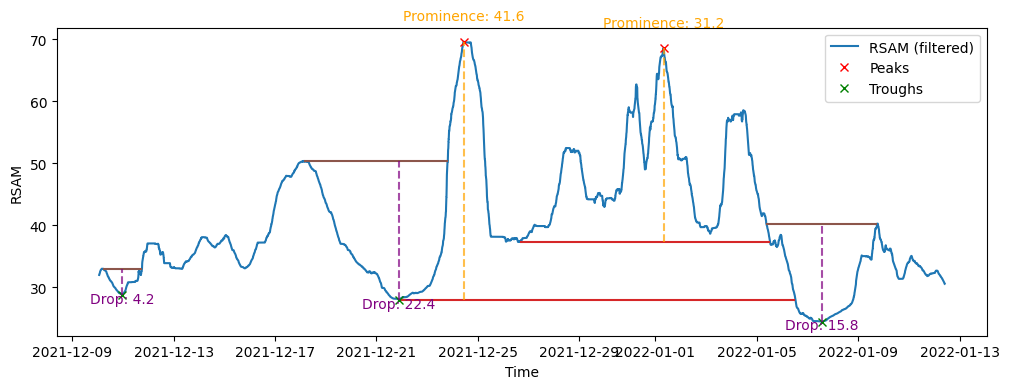

In [ ]:
DISTANCE_PEAKS = len(rsam_filtered[0]) // 10 
HEIGHT_THRESHOLD = 90 
def analyze_and_plot_Rsam(rsam_signals, dates, plot= False): 
    for index, rsam_signal in enumerate(rsam_signals): 
        dates_arr = np.array(dates[index]) 
        # Remove NaNs 
        mask = rsam_signal.notna().values
        rsam_clean = rsam_signal.values[mask] 
        dates_clean = dates_arr[mask] 
        # Create an inverted copy for minima detection 
        rsam_inverted = -rsam_clean 
        if len(rsam_clean) == 0: 
            print("No valid RSAM data to analyze in this window.") 
        else: 
            # Highs (Peaks) 
            # # Take the highest peaks above the threshold 
            h_thresh = np.percentile(rsam_clean, HEIGHT_THRESHOLD) 
            h_peaks, _ = signal.find_peaks(rsam_clean, distance=DISTANCE_PEAKS, height=h_thresh) 
            h_results_full = signal.peak_widths(rsam_clean, h_peaks, rel_height=1.0) 
            # Find the prominence of the high peaks 
            h_prominences= signal.peak_prominences(rsam_clean, h_peaks)[0] 
            # Lows 
            # Take the lowest peaks following the threshold 
            l_thresh = np.percentile(rsam_inverted, HEIGHT_THRESHOLD) 
            l_peaks, _ = signal.find_peaks(rsam_inverted, distance=DISTANCE_PEAKS, height=l_thresh) 
            l_results_full = signal.peak_widths(rsam_inverted, l_peaks, rel_height=1.0) 
            # Find the depth of the drops 
            l_prominences= signal.peak_prominences(rsam_inverted, l_peaks)[0] 
            if plot: 
                # Plot 
                plt.figure(figsize=(12, 4)) 
                plt.plot(dates_clean, rsam_clean, label='RSAM (filtered)') 
                # Plot Highs
                if h_peaks.size > 0: 
                    plt.plot(dates_clean[h_peaks], rsam_clean[h_peaks], "x", color='red', label='Peaks') 
                    plt.hlines(h_results_full[1], dates_clean[h_results_full[2].astype(int)], dates_clean[h_results_full[3].astype(int)], color="C3") 
                    # Annotate Peak Prominence 
                    for i, peak_idx in enumerate(h_peaks): 
                        prominence = h_prominences[i] 
                        peak_date = dates_clean[peak_idx] 
                        peak_val = rsam_clean[peak_idx] 
                        # Draw line showing the prominence 
                        plt.vlines(x=peak_date, ymin=peak_val - prominence, ymax=peak_val, color='orange', linestyle='--', alpha=0.7) 
                        # Add text label for the prominence 
                        plt.text(peak_date, peak_val + (peak_val*0.05), f'Prominence: {prominence:.1f}', color='orange', ha='center') 
                        # Plot Lows 
                if l_peaks.size > 0: 
                    # Plot markers at positive rsam_clean values (remove the negative sign) 
                    plt.plot(dates_clean[l_peaks], rsam_clean[l_peaks], "x", color='green', label='Troughs') 
                    # Height lines must be inverted back to positive for plotting 
                    # l_results[1] contains the height (y-value). Since we calculated on inverted data, 
                    # these y-values are negative. We multiply by -1 to plot them on the positive chart. 
                    plt.hlines(-l_results_full[1], dates_clean[l_results_full[2].astype(int)], dates_clean[l_results_full[3].astype(int)], color="C5")
                    # Annotate Drop Depth 
                    for i, peak_idx in enumerate(l_peaks):
                        depth = l_prominences[i] 
                        trough_date = dates_clean[peak_idx] 
                        trough_val = rsam_clean[peak_idx] 
                        # Draw line showing the drop magnitude 
                        plt.vlines(x=trough_date, ymin=trough_val, ymax=trough_val + depth, color='purple', linestyle='--', alpha=0.7) 
                        # Add text label for the depth 
                        plt.text(trough_date, trough_val - (trough_val*0.05), f'Drop: {depth:.1f}', color='purple', ha='center') 
                    plt.xlabel('Time') 
                    plt.ylabel('RSAM') 
                    plt.legend() 
                    plt.show() 
                    return h_peaks, h_results_full, l_peaks, l_results_full, l_prominences
info = analyze_and_plot_Rsam(rsam_filtered, dates, True)